# EXP-30 — Calibration Curve Analysis

**Question:** When our model says 70% chance of home win, does it actually happen 70% of the time?

A perfectly calibrated model lies on the diagonal. Overconfident models curve below it. Underconfident models curve above.

**Why this matters:** Log loss directly penalizes miscalibration. Understanding where the model is over/underconfident tells us what to fix next.

In [8]:
import numpy as np
import pandas as pd
import joblib, json
import matplotlib.pyplot as plt
import matplotlib
plt.style.use('dark_background')
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.facecolor'] = '#0A0A0A'
matplotlib.rcParams['axes.facecolor'] = '#111111'
matplotlib.rcParams['axes.edgecolor'] = '#1A1A1A'
matplotlib.rcParams['axes.labelcolor'] = '#A1A1AA'
matplotlib.rcParams['xtick.color'] = '#A1A1AA'
matplotlib.rcParams['ytick.color'] = '#A1A1AA'
matplotlib.rcParams['text.color'] = '#FFFFFF'
matplotlib.rcParams['grid.color'] = '#1A1A1A'
matplotlib.rcParams['grid.linewidth'] = 0.8
from pathlib import Path
from sklearn.calibration import calibration_curve
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

PROCESSED_DIR = Path('../data/processed')
MODELS_DIR    = Path('../models')
print('Libraries loaded.')

Libraries loaded.


In [9]:
# Load model + data
model_bundle = joblib.load(MODELS_DIR / 'best_model.pkl')
xgb_model = model_bundle['xgb']
rf_model  = model_bundle['rf']
W_XGB, W_RF, W_DC = model_bundle['w_xgb'], model_bundle['w_rf'], model_bundle['w_dc']

scaler    = joblib.load(MODELS_DIR / 'scaler.pkl')
le        = joblib.load(MODELS_DIR / 'label_encoder.pkl')
feat_cols = joblib.load(MODELS_DIR / 'feature_cols.pkl')

train_df = pd.read_csv(PROCESSED_DIR / 'train_dc.csv')
test_df  = pd.read_csv(PROCESSED_DIR / 'test_dc.csv')

y_train = le.fit_transform(train_df['outcome'].values)
y_test  = le.transform(test_df['outcome'].values)

X_test_s = scaler.transform(test_df[feat_cols].values)

# Get predictions
xgb_p = xgb_model.predict_proba(X_test_s)
rf_p  = rf_model.predict_proba(X_test_s)

dc_p = np.column_stack([
    test_df['dc_away_win_prob'].values,
    test_df['dc_draw_prob'].values,
    test_df['dc_home_win_prob'].values,
])
dc_p = dc_p / dc_p.sum(axis=1, keepdims=True)

# Final blend: XGB*4 + RF*1 + DC*5
y_pred_proba = (W_XGB*xgb_p + W_RF*rf_p + W_DC*dc_p) / (W_XGB + W_RF + W_DC)

print(f'Model: XGB*{W_XGB} + RF*{W_RF} + DC*{W_DC}')
print(f'Test samples: {len(y_test):,}')
print(f'Classes: {le.classes_}  (0=away_win, 1=draw, 2=home_win)')
print(f'Overall log loss: {log_loss(y_test, y_pred_proba):.4f}')

Model: XGB*4 + RF*1 + DC*5
Test samples: 3,313
Classes: ['away_win' 'draw' 'home_win']  (0=away_win, 1=draw, 2=home_win)
Overall log loss: 0.7988


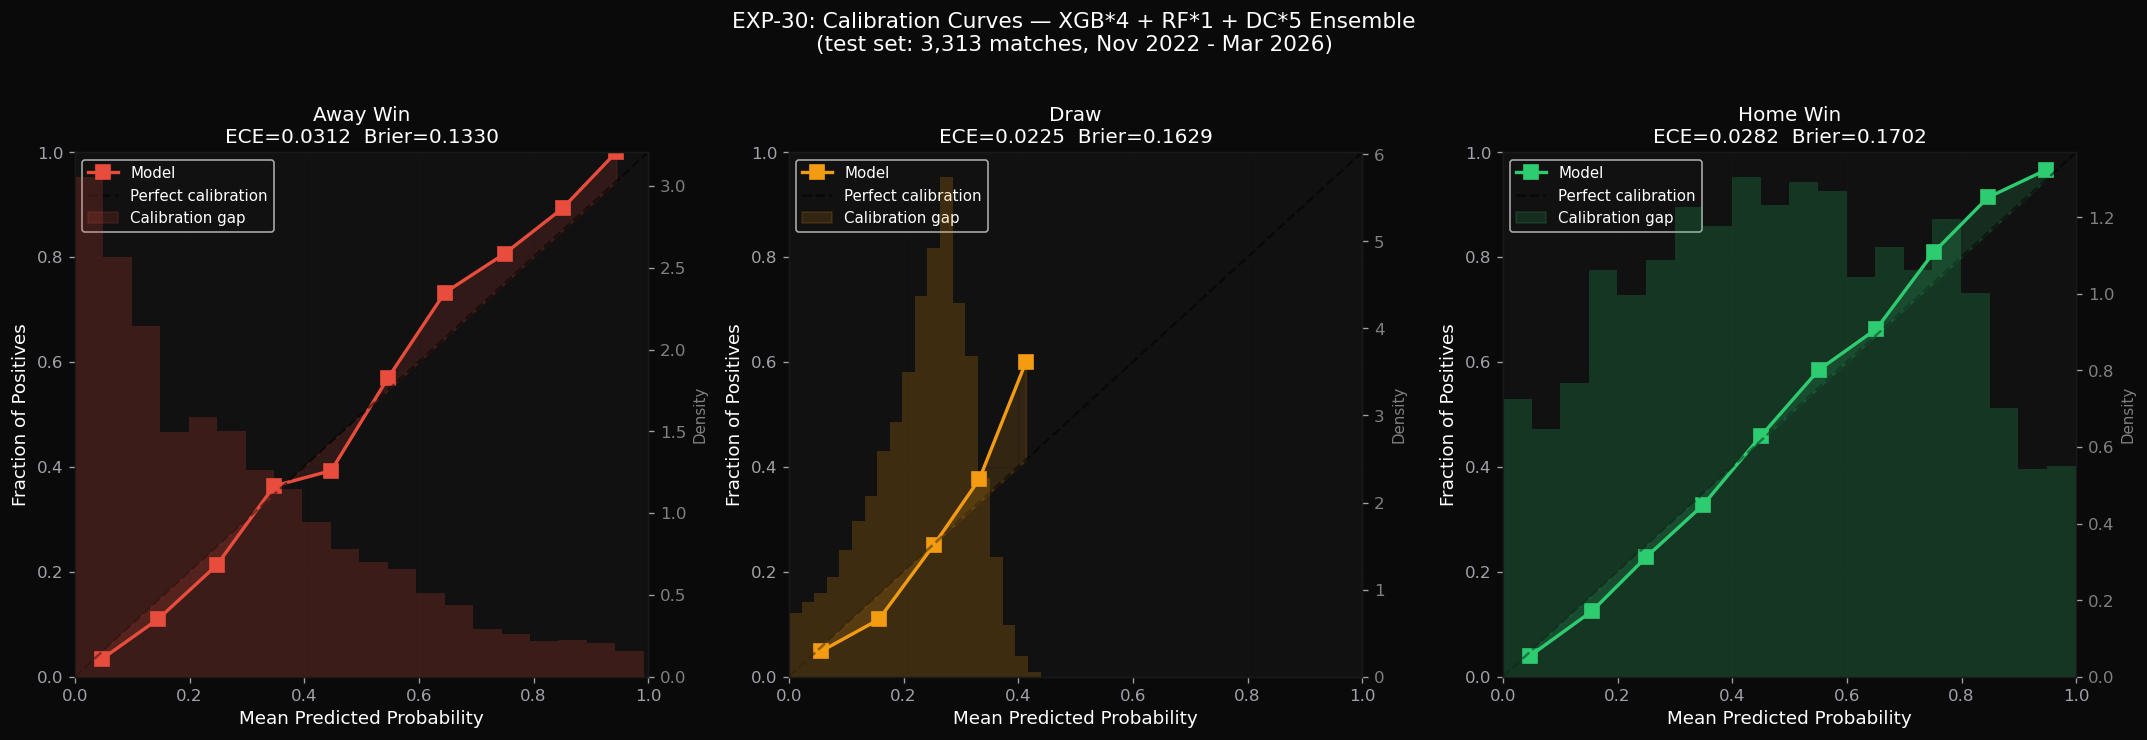


ECE scores: Away=0.0312  Draw=0.0225  Home=0.0282
Mean ECE: 0.0273


In [10]:
# Calibration curves for all 3 classes
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

class_names = ['Away Win', 'Draw', 'Home Win']
colors = ['#e74c3c', '#f39c12', '#2ecc71']
ece_scores = []

for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
    ax = axes[cls_idx]

    # Binary: is this class the outcome?
    y_binary = (y_test == cls_idx).astype(int)
    probs = y_pred_proba[:, cls_idx]

    # Calibration curve - 10 bins
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_binary, probs, n_bins=10, strategy='uniform'
    )

    # Plot
    ax.plot(mean_predicted_value, fraction_of_positives,
            's-', color=color, linewidth=2, markersize=8, label='Model')
    ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.fill_between(mean_predicted_value,
                    fraction_of_positives, mean_predicted_value,
                    alpha=0.15, color=color, label='Calibration gap')

    # ECE calculation
    bin_edges = np.linspace(0, 1, 11)
    ece = 0
    for i in range(10):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() > 0:
            bin_acc  = y_binary[mask].mean()
            bin_conf = probs[mask].mean()
            ece += mask.sum() / len(probs) * abs(bin_acc - bin_conf)
    ece_scores.append(ece)

    # Brier score
    brier = brier_score_loss(y_binary, probs)

    ax.set_xlabel('Mean Predicted Probability', fontsize=11)
    ax.set_ylabel('Fraction of Positives', fontsize=11)
    ax.set_title(f'{cls_name}\nECE={ece:.4f}  Brier={brier:.4f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

    # Frequency histogram (secondary)
    ax2 = ax.twinx()
    ax2.hist(probs, bins=20, alpha=0.2, color=color, density=True)
    ax2.set_ylabel('Density', fontsize=9, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')

plt.suptitle('EXP-30: Calibration Curves — XGB*4 + RF*1 + DC*5 Ensemble\n(test set: 3,313 matches, Nov 2022 - Mar 2026)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nECE scores: Away={ece_scores[0]:.4f}  Draw={ece_scores[1]:.4f}  Home={ece_scores[2]:.4f}')
print(f'Mean ECE: {np.mean(ece_scores):.4f}')

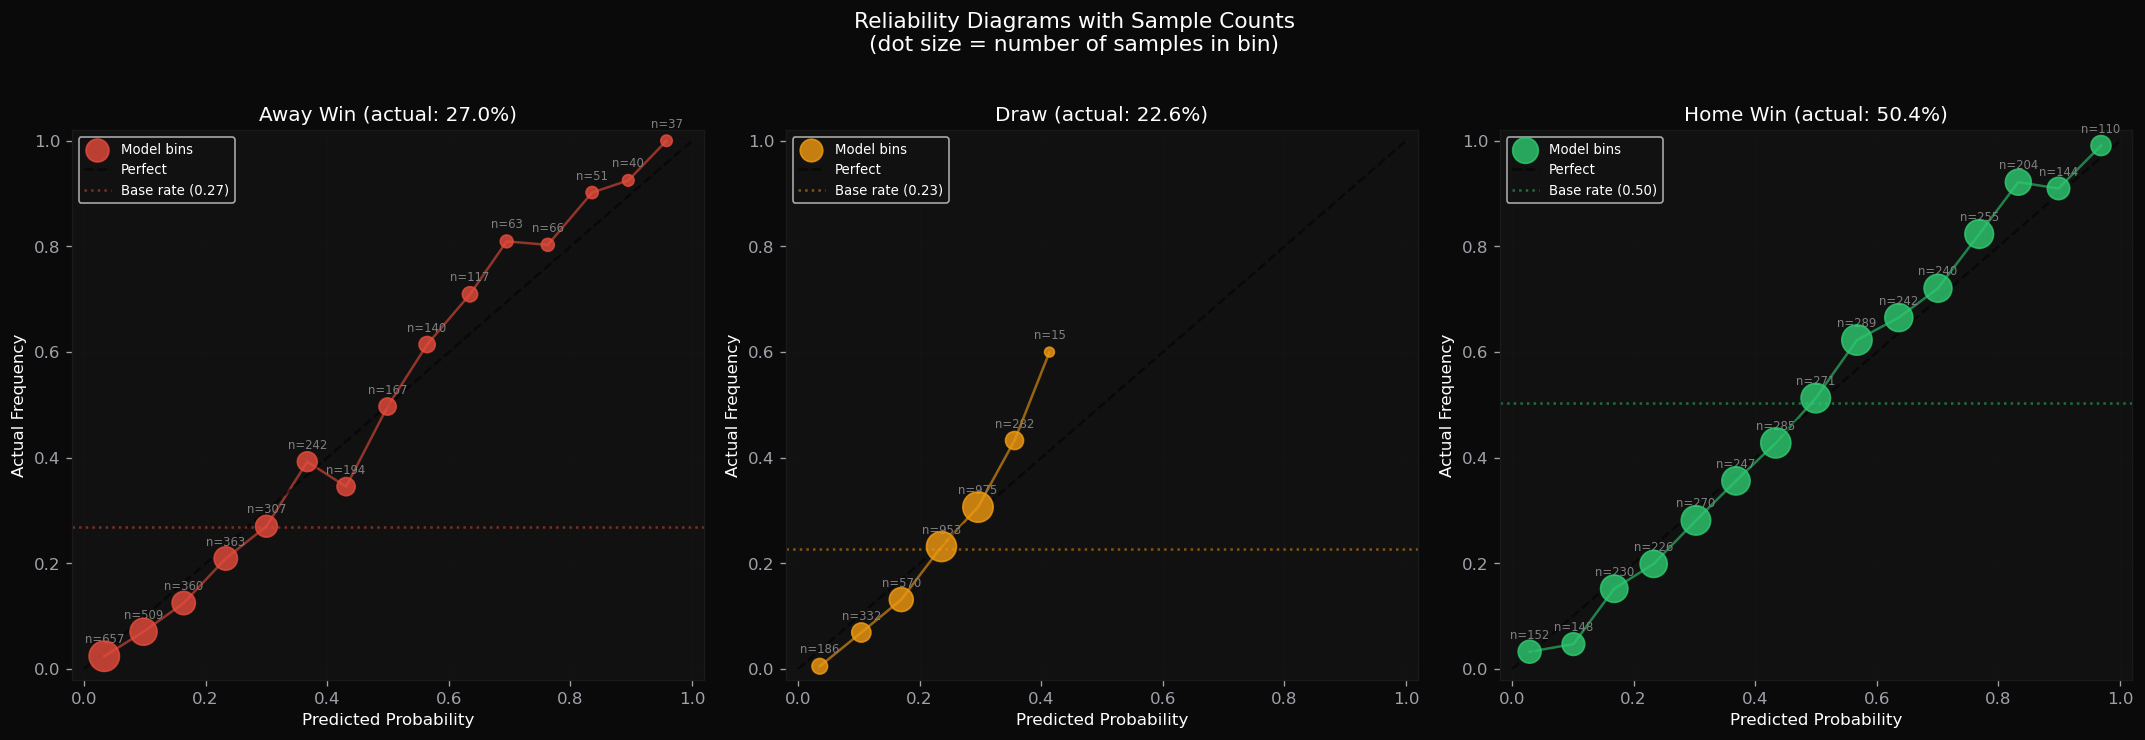

In [11]:
# Reliability diagram with confidence intervals + per-bin sample counts
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for cls_idx, (cls_name, color) in enumerate(zip(class_names, colors)):
    ax = axes[cls_idx]
    y_binary = (y_test == cls_idx).astype(int)
    probs = y_pred_proba[:, cls_idx]

    # 15 bins for more detail
    bin_edges = np.linspace(0, 1, 16)
    bin_centers, bin_acc, bin_n = [], [], []

    for i in range(15):
        mask = (probs >= bin_edges[i]) & (probs < bin_edges[i+1])
        if mask.sum() >= 5:  # min 5 samples
            bin_centers.append(probs[mask].mean())
            bin_acc.append(y_binary[mask].mean())
            bin_n.append(mask.sum())

    bin_centers = np.array(bin_centers)
    bin_acc     = np.array(bin_acc)
    bin_n       = np.array(bin_n)

    # Size dots by sample count
    sizes = (bin_n / bin_n.max()) * 300 + 30
    sc = ax.scatter(bin_centers, bin_acc, s=sizes, c=color, alpha=0.8, zorder=5, label='Model bins')
    ax.plot(bin_centers, bin_acc, '-', color=color, alpha=0.6, linewidth=1.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Perfect')

    # Annotate sample counts
    for x, y, n in zip(bin_centers, bin_acc, bin_n):
        ax.annotate(f'n={n}', (x, y), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=7, color='gray')

    # Base rate line
    base_rate = y_binary.mean()
    ax.axhline(base_rate, color=color, linestyle=':', alpha=0.5,
               label=f'Base rate ({base_rate:.2f})')

    actual_pct = y_binary.mean() * 100
    ax.set_title(f'{cls_name} (actual: {actual_pct:.1f}%)', fontsize=12)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Actual Frequency')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.3)

plt.suptitle('Reliability Diagrams with Sample Counts\n(dot size = number of samples in bin)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/processed/reliability_diagrams.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Summary scorecard
print('='*55)
print('EXP-30 CALIBRATION SCORECARD')
print('='*55)
print(f'Model: XGB*{W_XGB} + RF*{W_RF} + DC*{W_DC} blend')
print(f'Test set: {len(y_test):,} matches')
print(f'Log Loss: {log_loss(y_test, y_pred_proba):.4f}')
print()

outcome_counts = pd.Series(y_test).value_counts().sort_index()
print('Class distribution:')
for i, name in enumerate(le.classes_):
    actual_rate = (y_test == i).mean()
    avg_pred    = y_pred_proba[:, i].mean()
    brier       = brier_score_loss((y_test==i).astype(int), y_pred_proba[:,i])
    print(f'  {name:10s}: actual={actual_rate:.3f}  avg_pred={avg_pred:.3f}  '
          f'bias={avg_pred-actual_rate:+.3f}  brier={brier:.4f}')

print()
print(f'Mean ECE: {np.mean(ece_scores):.4f}')
print()
print('Interpretation:')
print('  bias > 0 = model overestimates this outcome')
print('  bias < 0 = model underestimates this outcome')
print('  ECE close to 0 = well calibrated')
print('='*55)

EXP-30 CALIBRATION SCORECARD
Model: XGB*4 + RF*1 + DC*5 blend
Test set: 3,313 matches
Log Loss: 0.7988

Class distribution:
  away_win  : actual=0.270  avg_pred=0.279  bias=+0.009  brier=0.1330
  draw      : actual=0.226  avg_pred=0.229  bias=+0.002  brier=0.1629
  home_win  : actual=0.504  avg_pred=0.492  bias=-0.012  brier=0.1702

Mean ECE: 0.0273

Interpretation:
  bias > 0 = model overestimates this outcome
  bias < 0 = model underestimates this outcome
  ECE close to 0 = well calibrated
